In [1]:
from numba import jit, njit
import kwant
from kwant.digest import uniform    # a (deterministic) pseudorandom number generator
import kwant.kpm


import scipy

import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace
from scipy.interpolate import interp1d


import cmath

from qutip import *
from joblib import Parallel, delayed
from scipy.ndimage import gaussian_filter


# --- Labels ---
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}


/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "


In [2]:
def corr_dis(L, W, a, xic):
    Nx = int(L/a)
    Ny = int(W/a)
    Vxy = np.random.normal(0, 1., size=(Ny, Nx))/(a) + 1j*0.0
    
    kkVxy = np.fft.fft2(Vxy)
    kx = 2*np.pi * np.fft.fftfreq(kkVxy.shape[1],d=a)
    ky = 2*np.pi * np.fft.fftfreq(kkVxy.shape[0],d=a)
    kx, ky = np.meshgrid(kx,ky)
    
    kVxy = np.multiply(kkVxy, np.exp( - .125 * xic**2. * (kx**2.+ky**2.)  ) ) * xic/np.sqrt(2.)
    
    Vxy = np.fft.ifft2(kVxy)
    Vxy = Vxy - np.sum(Vxy)/(1.*Nx*Ny)

    return Vxy

In [3]:
def v_img_singleside(W, N, min_l):
    arr_x = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(np.abs( arr_x ))
    return arr_V


def v_img(W, N, min_l):
    arr_V = []
    arr_x = np.linspace(-W/2, W/2, N)
    d = 1000*W + 2*min_l
    for x in arr_x:
        V = 0
        nf = 50000
        n_Z = np.linspace( -nf, nf, 2*nf+1)
        for n in n_Z:
            if n != 0:
                V += ( 1./(2*np.abs(n)) - 1./(2.*np.abs(n+500*(x)/d )) )
        if x < 0:
            arr_V.append(V)
        else:
            arr_V.append(V)
    return np.asarray(arr_V)/d*1000


def v_expcutoff_img_singleside(W, N, min_l, xiV):
    arr_x = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(np.abs( arr_x ))*np.exp( -(arr_x-min_l)**2/(2*xiV**2) )
    #arr_V = - 1./(np.abs( arr_x )) /( np.exp( (arr_x-min_l - xiV)/(.01*xiV) ) + 1 )
    return arr_V

In [4]:
def load_Ux(filename):
    # ---- Read numerical columns ----
    data = np.loadtxt(filename)

    vx     = data[:, 0]
    vU     = data[:, 1]
    vnum_e = data[:, 2]
    dnum_e = data[:, 3]

    # ---- Read metadata from header ----
    mu  = None
    omB = None

    with open(filename, "r") as f:
        for line in f:
            if "mu =" in line:
                mu = float(line.split("=")[1])
            if "omB =" in line:
                omB = float(line.split("=")[1])

    return vx, vU, vnum_e, dnum_e, mu, omB

vx, vU, vnum_e, compress, mu_dim, omB_dim = load_Ux("Ux.dat")
B = omB_dim/1.76    #in T
lB_dim = 25/B**.5   #in nm

dx_dim = abs(vx[1]-vx[0])


In [5]:
d = vx[-1]/.9999
f_U = interp1d(vx, vU, kind="cubic", bounds_error=False, fill_value="extrapolate")
f_N = interp1d(vx, vnum_e, kind="cubic", bounds_error=False, fill_value="extrapolate")
f_comp = interp1d(vx, compress, kind="cubic", bounds_error=False, fill_value="extrapolate")

In [6]:

Ncore = 5       #number of cores used in the calculation
iter_dis = 1

t = 1   # hopping rate for kwant
W = 700  # spatial width of the system ( Nx )
L = 200  # spatial length of the system ( Ny )

new_vx = np.linspace(-d*.9999,d*.9999, W)
dx = abs(new_vx[1]-new_vx[0])
U_conf = f_U(new_vx)/omB_dim   # x_small: (M,)
bare_den = f_N(new_vx)
compr_new = f_comp(new_vx)

lat = kwant.lattice.square(a=1, norbs=2)

#BandW0 = 40*1   #total bandwidth in meV
#l0 = np.sqrt(568/BandW0*8.) * 10**(-3.) # sqrt( \hbar^2/(2m*)/(\hbar J)) here I took \hbar^2/(2m*) = 568 nm^2 meV (GaAs) and \hbar J = BW/8 in micron!
#B0 = 4.14*10**3. / (l0 * 10**3.)**2. #in T, as 2\pi \hbar/e 1/a^2
#print(dx, l0)
# Adimensional magnetic flux
alpha = dx**2/lB_dim**2. /(2.*np.pi)
#alpha = B/B0
lB = 1./np.sqrt(2*np.pi*alpha)
omB = 4*np.pi*alpha
Zeeman = omB/3

U_conf = U_conf*omB

EF = mu_dim/omB_dim*omB

print(int(1./alpha),lB)

xic = lB * 1.      # Correlation length and definition of disorder-potential array
Udis = corr_dis(int(L), int(W), 1, xic)
E_dis = omB * .0001                   # disorder amplitude in cyclotrons


# Define Pauli matrices
sigma_0 = np.array([[1, 0], [0, 1]])  # Identity (spin-independent)
sigma_x = np.array([[0, 1], [1, 0]])  # Pauli X
sigma_y = np.array([[0, -1j], [1j, 0]])  # Pauli Y
sigma_z = np.array([[1, 0], [0, -1]])  # Zeeman term


def onsite(site, params):
    xi, yi = site.pos

    om0 = 4 * t * sigma_0  # Original onsite energy
    omRan = params.E_dis * params.Udis[int(yi)][int(xi)] * sigma_0  # Disorder
    omConf = params.Uconf[int(yi)] * sigma_0  # Disorder

    H_Zeeman = Zeeman / 2 * sigma_z  # Zeeman term (splits spin up/down)

    return om0 + omRan + omConf + H_Zeeman  # Return as a 2x2 matrix

def hopping(site_i, site_j, params):
    xi, yi = site_i.pos
    xj, yj = site_j.pos

    phase = -1j * 2 * np.pi * params.alpha * (xi - xj) * (yi + yj) / 2.
    
    return -t * np.exp(phase) * sigma_0  # Spin-preserving hopping

def onsite_lead(site, params):
    return 4 * t * sigma_0 + (Zeeman / 2) * sigma_z  # Zeeman in leads

def hopping_lead(site_i, site_j, params):
    return -t * sigma_0  # Spin-independent hopping

sys = kwant.Builder()
sys[(lat(x, y) for x in range(L) for y in range(W))] = onsite
sys[lat.neighbors()] = hopping

sym_left_lead = kwant.TranslationalSymmetry((-1, 0))
left_lead = kwant.Builder(sym_left_lead)
left_lead[(lat(0, y) for y in range(W))] = onsite_lead
left_lead[lat.neighbors()] = hopping_lead
sys.attach_lead(left_lead)
sys.attach_lead(left_lead.reversed())

sys = sys.finalized()

59 3.089481698478517


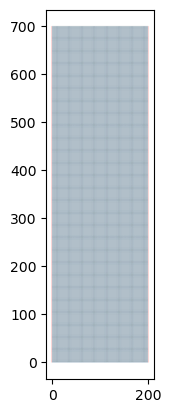

(0.0, 10.0)

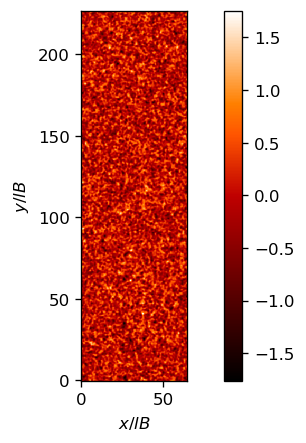

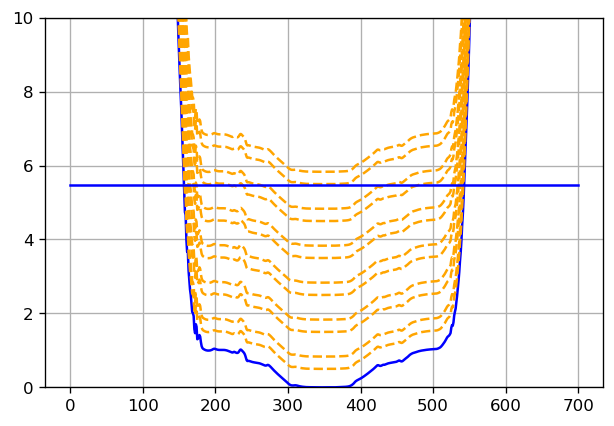

In [7]:
#plot some structural kwant stuff
kwant.plot(sys);

xvec = np.linspace(0, L-1, int(L) )
yvec = np.linspace(0, W-1, int(W) )
X, Y = np.meshgrid(xvec, yvec)

fig_W, ax_W = plt.subplots(dpi=120, figsize=(8, 4))
vmin = 0.
vmax = 1.000
Wmap_plot = ax_W.pcolormesh(X/lB, Y/lB, (Udis.real), cmap='gist_heat', alpha=1)  #, vmin=vmin, vmax=vmax)
fig_W.colorbar(Wmap_plot)
ax_W.set_xlabel(r'$x/lB$')
ax_W.set_ylabel(r'$y/lB$')
ax_W.set_aspect('equal')


fig_Img, ax_Img = plt.subplots(dpi=120, figsize=(6, 4))
ax_Img.plot( yvec, U_conf/omB, color='blue' )
for l in range(6):
    ax_Img.plot( yvec, U_conf/omB+.5 + l, color='orange', linestyle='--' )
    ax_Img.plot( yvec, U_conf/omB+.5 + l + Zeeman/omB, color='orange', linestyle='--' )




ax_Img.plot( yvec, EF/omB*np.ones(len(yvec)), color='blue' )

ax_Img.grid()

ax_Img.set_ylim(0,10)




In [8]:
params =SimpleNamespace( alpha=alpha, E_dis=E_dis, Udis=Udis, Uconf = U_conf )
wfs = kwant.wave_function(sys, energy=EF, args=[params])
scattering_wf = wfs(0)
psi = scattering_wf


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_24255/2727522972.py:2: KwantDeprecationWarning:

The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.

/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/common.py:151: KwantDeprecationWarning:

The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.

/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/common.py:204: KwantDeprecationWarning:

The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.

/opt/anaconda3/lib/python3.12/site-packages/kwant/system.py:330: KwantDeprecationWarning:

The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.

/opt/anaconda3/lib/python3.12/site-packages/kwant/system.py:291: KwantDeprecationWarning:

The 

In [9]:
psi = np.sum(abs(wfs(0))**2, axis=0)        # shape: (nsites*norbs,) complex
#psi_site = psi.reshape(-1, 2)  #to obtain spin-resolved density
#dens_up   = abs(psi_site[:, 0])**2
#dens_down = abs(psi_site[:, 1])**2

norbs = 2
density = (abs(psi)**2).reshape(-1, norbs).sum(axis=1)   # shape: (nsites,)

/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_24255/1117103771.py:3: RuntimeWarning:

The plotted data contains 1.76% of values overflowing upper limit 4.90648 



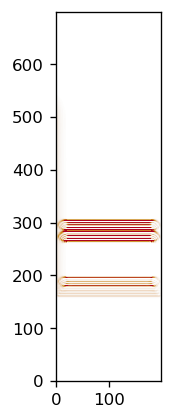

In [10]:
fig, ax = plt.subplots(dpi=120, figsize=(8, 4))

kwant.plotter.map(sys, (density), ax=ax, show=True)

In [11]:
sites = sys.sites
coords = np.array([site.pos for site in sites])

x = coords[:, 0]
y = coords[:, 1]

density_2D = density.reshape(L, W)   # rows = x, cols = y
avg_den = np.sum(density_2D, axis=0)/(L*dx)


In [12]:
    
def kernel_CSG(vx, vt, d):
    l_cut = 2.  #in nm
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    mK = np.log( np.abs( (np.sqrt( (d**2 - mx**2.)*(d**2.-mt**2) ) + d**2 - mx*mt )/(2*d**2) ) ) - np.log( np.abs((mx-mt + 1e-12)/(2*d)) )*(1-np.exp(-np.abs(mx-mt)/l_cut ))    
    
    return mK - np.amin(mK)*0

    
def kernel_IMG(vx, vt, d):
    l_cut = 2.  #in nm
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    mK = np.log( np.abs( (np.sqrt( (d**2 - mx**2.)*(d**2.-mt**2) ) + d**2 - mx*mt )/(2*d**2) ) )   
    
    return mK - np.amin(mK)*0

@njit
def number_e(T, vx, vU, vD, vE, mu):    #T in meV
    num_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    
    for ne, E in enumerate(vE):
        F = 1./( np.exp( (E + vU - mu)/T ) + 1. )
        num_e += dE*vD[ne] * F
    
    return num_e

In [13]:
def fun_compr(T, vx, vU, vD, vE, mu):    #T in meV
    dnum_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    if T > .01:
        for ne, E1 in enumerate(vE):
            E = E1
            #dF = np.exp( (E + vU - mu)/T ) /( np.exp( (E + vU - mu)/T ) + 1. )**2./T 
            logdFT = ( (E + vU - mu)/T ) - np.log( np.exp( (E + vU - mu)/T ) + 1. )*2.
            dF = np.exp(logdFT)/T
            dnum_e += dE*vD[ne] * dF
    else:
        for nx, x in enumerate(vx):
            ne = np.argmin(np.abs(vE - (mu - vU[nx] ) ))
            dnum_e[nx] = vD[ne]
    
    return dnum_e

def dos_B( B, vE, gam0 ):
    lB = 25/B**.5   #in nm and B in T
    omB = 1.76 * B  #in meV and B in T
    EZ = omB/3.
    Gam = gam0 * omB * (10/B)**.5
    vD = np.zeros( len(vE) )
    for n in range(150):
        epsn = (.5+n)*omB
        vD += 1./(2*np.pi*lB**2.) * ( np.exp( - (epsn - vE)**2./Gam**2. )/(np.pi*Gam**2.)**.5 + np.exp( - (epsn+EZ - vE)**2./Gam**2. )/(np.pi*Gam**2.)**.5 )
    
    return vD

In [14]:
r_scale = 1e-4 * 3

In [15]:
kappa0 = 1.44/13. * 10e3  #in meV * nm

new_vt = new_vx.copy()
mK = kernel_CSG(new_vx, new_vt, d)
mK_img = kernel_IMG(new_vx, new_vt, d)

matrix0 = - kappa0 * dx * np.multiply(mK , compr_new[np.newaxis, :])
matrix_inv = np.eye(len(new_vx)) -  kappa0 * dx * np.multiply(mK , compr_new[np.newaxis, :])
MMmatrix = scipy.linalg.inv(matrix_inv)

dU_full = -  kappa0 * dx * np.dot(mK,  avg_den/(dx**2)*r_scale)
dU_img = -  kappa0 * dx * np.dot(mK_img,  avg_den/(dx**2)*r_scale) * 5
dU_img = np.matmul( MMmatrix, dU_img )


In [16]:
modifiedU = (-dU_img)/omB_dim + U_conf/omB

gam0 = 0.02  #adimensional width of the LLs
T = .01 #in meV 0.01 => 0.116 K
vE = np.linspace(.0001, 8, 2000) * omB_dim
vD = dos_B( B, vE, gam0 )
modifiedN = number_e(T, new_vx, modifiedU*omB_dim, vD, vE, mu_dim)

In [17]:
compr_new = fun_compr(T, new_vx, modifiedU*omB_dim, vD, vE, mu_dim)
compr_new = gaussian_filter(compr_new, sigma=2)

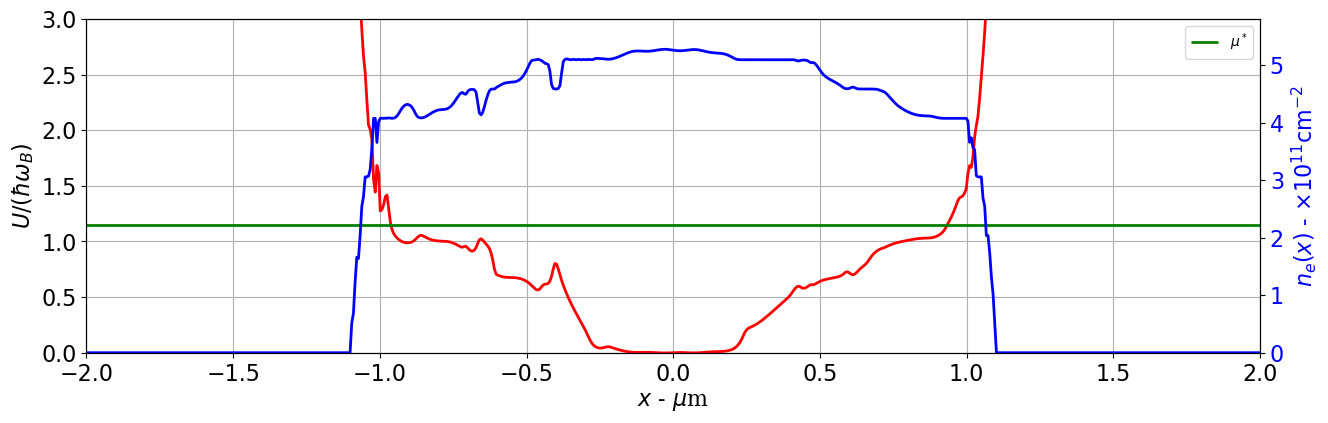

In [18]:

modifiedN_1 = avg_den/(dx**2)*r_scale + modifiedN

ymax = 3

fig, ax = plt.subplots()

# --- LEFT Y-AXIS (potential) ---
ax.plot(new_vx*1e-3, modifiedU, color='red', linewidth=2)
ax.hlines(EF, xmin=-d*1e-3, xmax=d*1e-3,
          color='green', linewidth=2, label=r"$\mu^*$")

ax.set_ylim(0, ymax)
ax.set_xlim(-d*1e-3, d*1e-3)

# --- RIGHT Y-AXIS (blue curve) ---
ax2 = ax.twinx()
ax2.plot(
    new_vx*1e-3,
    modifiedN_1*1e3,
    color='blue',
    linewidth=2
)

ax2.set_ylim(0, np.amax(modifiedN_1*1e3)*1.1)   # same scale for visual alignment
ax2.tick_params(axis='y', labelcolor='blue')



ax.set_xlabel(r"$x$ - $\mu$m", fontdict=font)
ax.set_ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
ax2.set_ylabel(r"$n_e(x)$ - $\times 10^{11} {\rm cm}^{-2}$", fontdict=font, color='blue')

# --- Tick styling ---
ax.tick_params(axis='both',
               labelsize=font['size'],
               labelcolor=font['color'])
ax2.tick_params(axis='y',
                labelsize=font['size'],
                labelcolor='blue')

ax.grid()
ax.legend()

# --- Figure size ---
fig.set_size_inches(340 / 25.4, 110 / 25.4)
fig.tight_layout()

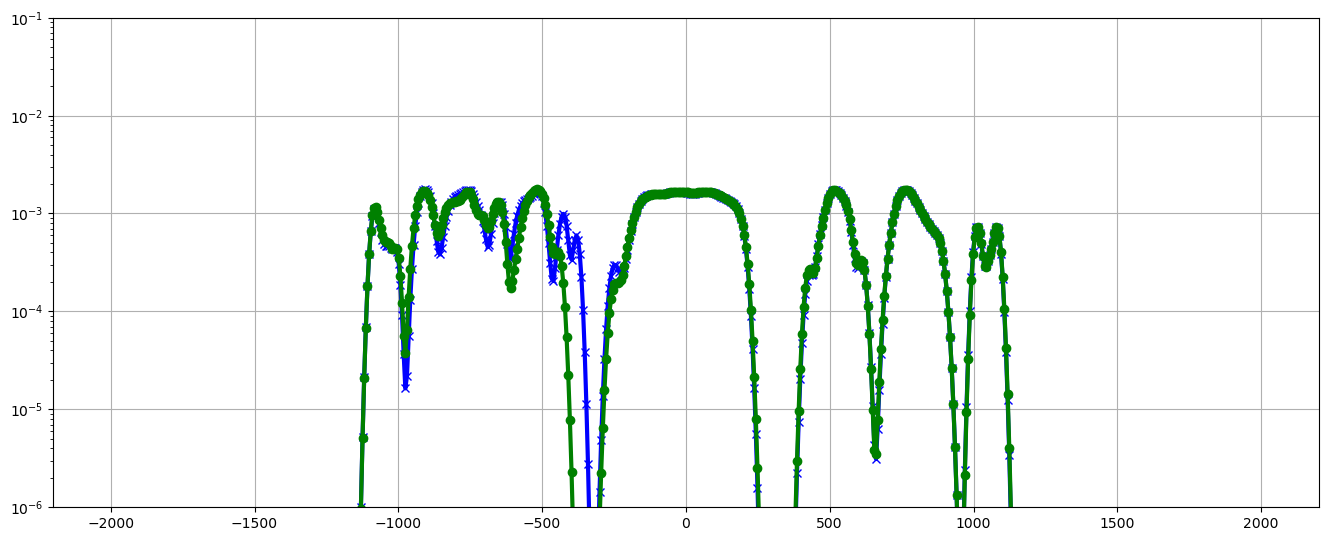

In [19]:
compress_smooth = gaussian_filter(compress, sigma=2)
plt.plot( new_vx, compr_new, color='blue', linewidth=3, marker='x' )
plt.plot( vx, compress, color='green', linewidth=3, marker='o' )


plt.yscale('log')
plt.ylim(1e-6,1e-1)
#plt.xlim(-1200,0)

plt.grid()

plt.gcf().set_size_inches(340 / 25.4, 140 / 25.4)
plt.tight_layout()

In [20]:
header = f"""Data file for U(x)
mu = {mu_dim}
omB = {omB_dim}
Columns:
1) x
2) U(x)
3) local density n_e(x)
4) compressibility dn_e(x)
"""

np.savetxt(
    "Ux.dat",
    np.column_stack([new_vx, (-dU_img) + U_conf/omB*omB_dim, modifiedN, compr_new]),
    header=header,
    fmt="%.8e",
    comments="# "
)